# Token Efficiency

Compare token usage across four inference regimes, for every model and benchmark:
- **nothink** — reasoning disabled (empty `<think></think>`, answer only)
- **best_prompt_style** — the onepass prompt style (concise/aspects/plansolve/budget,
  see notebook 05) that gave the best pass@1 for that model/benchmark
- **twopass** — best transition budget, think-overflow's method at whichever swept
  `max_think_tokens` cap gave the best pass@1 for that model/benchmark
- **onepass** — reasoning enabled (default), unconstrained

Three figures are produced:
- `figures/06_efficiency_output_tokens.png` — mean total output tokens per benchmark
- `figures/06_efficiency_cost_per_correct.png` — tokens spent per correct answer
  (`mean_tokens / pass@1`) per benchmark, log scale
- `figures/06_efficiency_average.png` — both metrics macro-averaged over all
  benchmarks, mean output tokens on top and cost per correct answer below

Averages are macro averages: every benchmark counts equally, regardless of how many
tasks it holds, so no single benchmark dominates.


In [1]:
"""Token usage comparison: reasoning disabled vs. best prompt style vs. best transition budget vs. default, across models and benchmarks."""

import json
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [2]:
# --- configuration ---

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path("../output")

# max token budget used in all greedy runs
MAX_TOKENS = 32768

# onepass prompt-style suffix keys swept for the "best prompt style" regime (see
# notebook 05) — the baseline ("none") is already covered by the default onepass bar
PROMPT_STYLE_KEYS: list[str] = ["concise", "aspects", "plansolve", "budget"]

# vibrant palette: ColorBrewer Set1 with yellow (#5) replaced by cyan and
# grey (#8) replaced by deep pink, for better on-white visibility
_P = [
    "#E41A1C",  # red
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#984EA3",  # purple
    "#FF7F00",  # orange
    "#00BCD4",  # cyan  (replaces Set1 yellow)
    "#A65628",  # brown
    "#F781BF",  # pink
    "#FF4081",  # deep pink  (replaces Set1 grey)
]

# colour groups by model family — colours match the SERIES dict in notebooks 02, 03 and 05:
#   qwen3 models → blue / teal / cyan (similar, distinct)
#   or / ocr     → purple / pink
#   olmo / llama → orange / brown
SERIES: dict[str, dict] = {
    "qwen3_8b": {"label": "Qwen3-8B", "model_key": "qwen3-8b", "colour": "#377EB8"},
    "qwen3_14b": {"label": "Qwen3-14B", "model_key": "qwen3-14b", "colour": "#009688"},
    "qwen3_32b": {"label": "Qwen3-32B", "model_key": "qwen3-32b", "colour": "#00BCD4"},
    "olmo_3_7b": {"label": "OLMo3-7B", "model_key": "olmo-3-7b", "colour": "#FF7F00"},
    "llama_r1_8b": {
        "label": "Llama-R1-8B",
        "model_key": "llama-r1-8b",
        "colour": "#A65628",
    },
    "or_7b": {"label": "OpenReason-7B", "model_key": "or-7b", "colour": "#984EA3"},
    "ocr_7b": {"label": "CodeReason-7B", "model_key": "ocr-7b", "colour": "#F781BF"},
}

# benchmarks to plot: display name → key prefix used in the output JSON filenames.
# matches notebooks 03 and 05's scope (code + crux benchmarks only)
DATASETS: dict[str, str] = {
    "EvalPlus": "code/evalplus_greedy",
    "BigCodeBench": "code/bigcodebench_greedy",
    "LiveCodeBench": "code/livecodebench_greedy",
    "CodeContests": "code/code_contests_greedy",
    "CRUX-Input": "crux/cruxeval_i_greedy",
    "CRUX-Output": "crux/cruxeval_o_greedy",
}

# the four regimes compared throughout this notebook: display label → fill style.
# order sets the left-to-right bar order within each model group.
# "reasoning enabled/disabled" wording matches the legend in notebook 03 (accuracy);
# "best prompt style" (see _peak_prompt_style_entry) and "best transition budget" (see
# _peak_budget_entry) are both onepass/twopass at whichever swept variant gave the
# best pass@1 for that model/benchmark, contrasted with the unconstrained default
REGIMES: dict[str, dict] = {
    "nothink": {"label": "Reasoning disabled", "alpha": 0.55, "hatch": None},
    "best_prompt_style": {"label": "Best prompt style", "alpha": 0.65, "hatch": "xxx"},
    "twopass": {"label": "Best transition budget", "alpha": 0.70, "hatch": "///"},
    "onepass": {"label": "Reasoning enabled (default)", "alpha": 0.90, "hatch": None},
}

# dark grey used for hatch lines and neutral legend swatches
_GREY = "#555555"

# font size constants — match notebooks 02, 03 and 05
TITLE_SIZE = 13
FONT_SIZE = 11
TICK_SIZE = 10

In [3]:
def _peak_budget_entry(twopass_data: dict, prefix: str) -> dict | None:
    """Find the twopass summary entry with the best pass@1 for a dataset prefix.

    Twopass entries are keyed "{prefix}_mx{MAX_TOKENS}_th{budget}_base", one per swept
    max_think_tokens budget. Ties are broken in favour of the lowest (cheapest) budget.
    Returns None when no twopass entry exists for this prefix.
    """
    prefix_mx = f"{prefix}_mx{MAX_TOKENS}_"
    th_keys = [
        k
        for k in twopass_data
        if k.startswith(prefix_mx) and k.endswith("_base") and "_th" in k
    ]
    if not th_keys:
        return None

    def _sort_key(key: str) -> tuple[float, int]:
        budget = int(key.split("_th")[1].split("_base")[0])
        return (twopass_data[key]["pass_at_1"], -budget)

    best_key = max(th_keys, key=_sort_key)
    return twopass_data[best_key]


def _peak_prompt_style_entry(onepass_data: dict, prefix: str) -> dict | None:
    """Find the onepass prompt-style entry with the best pass@1 for a dataset prefix.

    Searches only the engineered styles in PROMPT_STYLE_KEYS (concise/aspects/plansolve/
    budget, see notebook 05) — the baseline is already covered by the plain onepass
    entry. Ties are broken in favour of fewer tokens. Returns None when none of the
    styles were run for this dataset prefix.
    """
    candidates = [
        entry
        for style in PROMPT_STYLE_KEYS
        if (entry := onepass_data.get(f"{prefix}_mx{MAX_TOKENS}_onepass_{style}"))
        is not None
    ]
    if not candidates:
        return None

    return max(
        candidates,
        key=lambda e: (
            e["pass_at_1"],
            -e["token_statistics"]["mean_completion_tokens_1"],
        ),
    )


def load_token_data() -> dict[str, dict[str, dict[str, dict]]]:
    """Load mean output tokens, pass@1 and cost-per-correct-answer for all four regimes.

    nothink: mean_completion_tokens_2 is the only generation pass — answer only, no
    reasoning. onepass: mean_completion_tokens_1 is the only generation pass — reasoning
    and answer combined (not separated at the token-count level). best_prompt_style: the
    onepass entry (still a single combined generation pass) for whichever swept prompt
    style gave the best pass@1 (see _peak_prompt_style_entry). twopass: uses whichever
    swept max_think_tokens budget gave the best pass@1 for that model/benchmark (see
    _peak_budget_entry); total tokens = mean_completion_tokens_1 (capped reasoning) +
    mean_completion_tokens_2 (recovery-phase answer).

    Cost-per-correct-answer (tokens / pass@1) is left as None wherever pass@1 is 0 or
    missing, since the cost of a correct answer is undefined when none was produced.

    Returns a nested dict: series_key → dataset_label → regime_key → {
        "tokens": float | None, "pass": float | None, "cost": float | None,
    }
    """
    results: dict[str, dict[str, dict[str, dict]]] = {}

    for series_key, series_info in SERIES.items():
        model_key = series_info["model_key"]
        results[series_key] = {ds_label: {} for ds_label in DATASETS}

        onepass_path = OUTPUT_DIR / f"{model_key}_onepass.json"
        nothink_path = OUTPUT_DIR / f"{model_key}_nothink.json"
        twopass_path = OUTPUT_DIR / f"{model_key}_twopass.json"

        onepass_data = json.load(open(onepass_path)) if onepass_path.exists() else {}
        nothink_data = json.load(open(nothink_path)) if nothink_path.exists() else {}
        twopass_data = json.load(open(twopass_path)) if twopass_path.exists() else {}

        for ds_label, prefix in DATASETS.items():
            onepass_entry = onepass_data.get(f"{prefix}_mx{MAX_TOKENS}_onepass")
            nothink_entry = nothink_data.get(f"{prefix}_mx{MAX_TOKENS}_nothink")
            style_entry = _peak_prompt_style_entry(onepass_data, prefix)
            peak_entry = _peak_budget_entry(twopass_data, prefix)

            if onepass_entry is None:
                print(f"  [skip] {series_key} / {ds_label} / onepass not found")
            if nothink_entry is None:
                print(f"  [skip] {series_key} / {ds_label} / nothink not found")
            if style_entry is None:
                print(
                    f"  [skip] {series_key} / {ds_label} / best_prompt_style not found"
                )
            if peak_entry is None:
                print(f"  [skip] {series_key} / {ds_label} / twopass not found")

            def _twopass_totals(
                entry: dict | None,
            ) -> tuple[float | None, float | None]:
                if entry is None:
                    return None, None
                ts = entry["token_statistics"]
                return (
                    ts["mean_completion_tokens_1"] + ts["mean_completion_tokens_2"],
                    entry["pass_at_1"],
                )

            peak_tokens, peak_pass = _twopass_totals(peak_entry)

            tokens_by_regime = {
                "nothink": nothink_entry["token_statistics"]["mean_completion_tokens_2"]
                if nothink_entry
                else None,
                "onepass": onepass_entry["token_statistics"]["mean_completion_tokens_1"]
                if onepass_entry
                else None,
                "best_prompt_style": style_entry["token_statistics"][
                    "mean_completion_tokens_1"
                ]
                if style_entry
                else None,
                "twopass": peak_tokens,
            }
            pass_by_regime = {
                "nothink": nothink_entry["pass_at_1"] if nothink_entry else None,
                "onepass": onepass_entry["pass_at_1"] if onepass_entry else None,
                "best_prompt_style": style_entry["pass_at_1"] if style_entry else None,
                "twopass": peak_pass,
            }

            for regime_key in REGIMES:
                tokens = tokens_by_regime[regime_key]
                pass_at_1 = pass_by_regime[regime_key]
                cost = tokens / pass_at_1 if tokens is not None and pass_at_1 else None
                results[series_key][ds_label][regime_key] = {
                    "tokens": tokens,
                    "pass": pass_at_1,
                    "cost": cost,
                }

    return results


all_data = load_token_data()
print("loaded token data for", len(all_data), "models")

loaded token data for 7 models


In [4]:
def _draw_regime_bars(
    ax: plt.Axes,
    get_bar,
    title: str,
    ylabel: str,
    yscale: str = "linear",
) -> None:
    """Draw one bar group per model on ax, with one bar per regime (nothink/twopass/onepass).

    get_bar(series_key, regime_key) returns the value for a single bar, or None to leave
    it out. Bar colour identifies the model and the alpha/hatch identifies the regime.
    """
    series_keys = list(SERIES.keys())
    regime_keys = list(REGIMES.keys())

    # bar geometry: the regimes of one model share an integer x position, 0.8 wide overall
    n_regimes = len(regime_keys)
    bar_width = 0.8 / n_regimes
    group_positions = np.arange(len(series_keys))

    for model_idx, series_key in enumerate(series_keys):
        colour = SERIES[series_key]["colour"]

        for regime_idx, regime_key in enumerate(regime_keys):
            value = get_bar(series_key, regime_key)
            if value is None:
                continue

            # offset each regime bar so the group stays centred on its x position
            offset = (regime_idx - (n_regimes - 1) / 2) * bar_width
            x = group_positions[model_idx] + offset
            fill = REGIMES[regime_key]

            ax.bar(
                x,
                value,
                width=bar_width,
                color=colour,
                alpha=fill["alpha"],
                hatch=fill["hatch"],
                edgecolor=_GREY if fill["hatch"] else "none",
                linewidth=0.5,
                zorder=3,
            )

    ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold")
    ax.set_xticks(group_positions)
    ax.set_xticklabels(
        [SERIES[sk]["label"] for sk in series_keys],
        rotation=20,
        ha="right",
        fontsize=TICK_SIZE,
    )
    ax.set_ylabel(ylabel, fontsize=FONT_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_SIZE)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    if yscale == "log":
        ax.set_yscale("log")
        # a few intermediate gridlines (2x and 5x each decade) alongside the major
        # decade lines — unlabelled, so they add reference without ticking up clutter.
        # "which=both" (every 2-9x minor tick) was too dense; major-only was too sparse
        ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=(2.0, 5.0)))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax.grid(axis="y", which="major", alpha=0.4, linewidth=0.8)
        ax.grid(axis="y", which="minor", alpha=0.25, linewidth=0.6)
    else:
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=0.5, linewidth=1.2)

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _add_regime_legend(fig: plt.Figure, y: float = 0.0) -> None:
    """Add a shared regime legend below the subplots.

    One neutral swatch per regime, drawn with the same alpha and hatch as its bars.
    """
    regime_keys = list(REGIMES.keys())
    legend_handles = [
        mpatches.Patch(
            facecolor=_GREY if REGIMES[rk]["hatch"] is None else "#DDDDDD",
            alpha=REGIMES[rk]["alpha"],
            hatch=REGIMES[rk]["hatch"],
            edgecolor=_GREY,
            label=REGIMES[rk]["label"],
        )
        for rk in regime_keys
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(regime_keys),
        fontsize=FONT_SIZE,
        frameon=False,
        bbox_to_anchor=(0.5, y),
    )


def plot_regime_bars(
    data: dict[str, dict[str, dict[str, dict]]],
    metric: str,
    ylabel: str,
    save_path: Path,
    n_cols: int = 2,
    yscale: str = "linear",
) -> None:
    """Plot grouped bar charts of one token metric per regime, for every benchmark.

    One subplot per benchmark in a 2-column grid matching notebooks 03 and 05, each
    holding one bar group per model and one bar per regime (nothink/twopass/onepass).
    Saves the figure as a PNG at save_path.
    """
    dataset_labels = list(DATASETS.keys())
    n_rows = (len(dataset_labels) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(13, 3.5 * n_rows),
        squeeze=False,
    )
    flat_axes = axes.flatten()

    for ax, ds_label in zip(flat_axes, dataset_labels):

        def get_bar(
            series_key: str,
            regime_key: str,
            ds_label: str = ds_label,
        ) -> float | None:
            return (
                data.get(series_key, {})
                .get(ds_label, {})
                .get(regime_key, {})
                .get(metric)
            )

        _draw_regime_bars(
            ax=ax, get_bar=get_bar, title=ds_label, ylabel=ylabel, yscale=yscale
        )

    # hide spare axes when the dataset count is not divisible by n_cols
    for ax in flat_axes[len(dataset_labels) :]:
        ax.set_visible(False)

    _add_regime_legend(fig)

    fig.tight_layout(rect=(0, 0.06, 1, 1), h_pad=2.5, w_pad=2)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved → {save_path}")
    plt.show()

saved → ../figures/06_efficiency_output_tokens.png


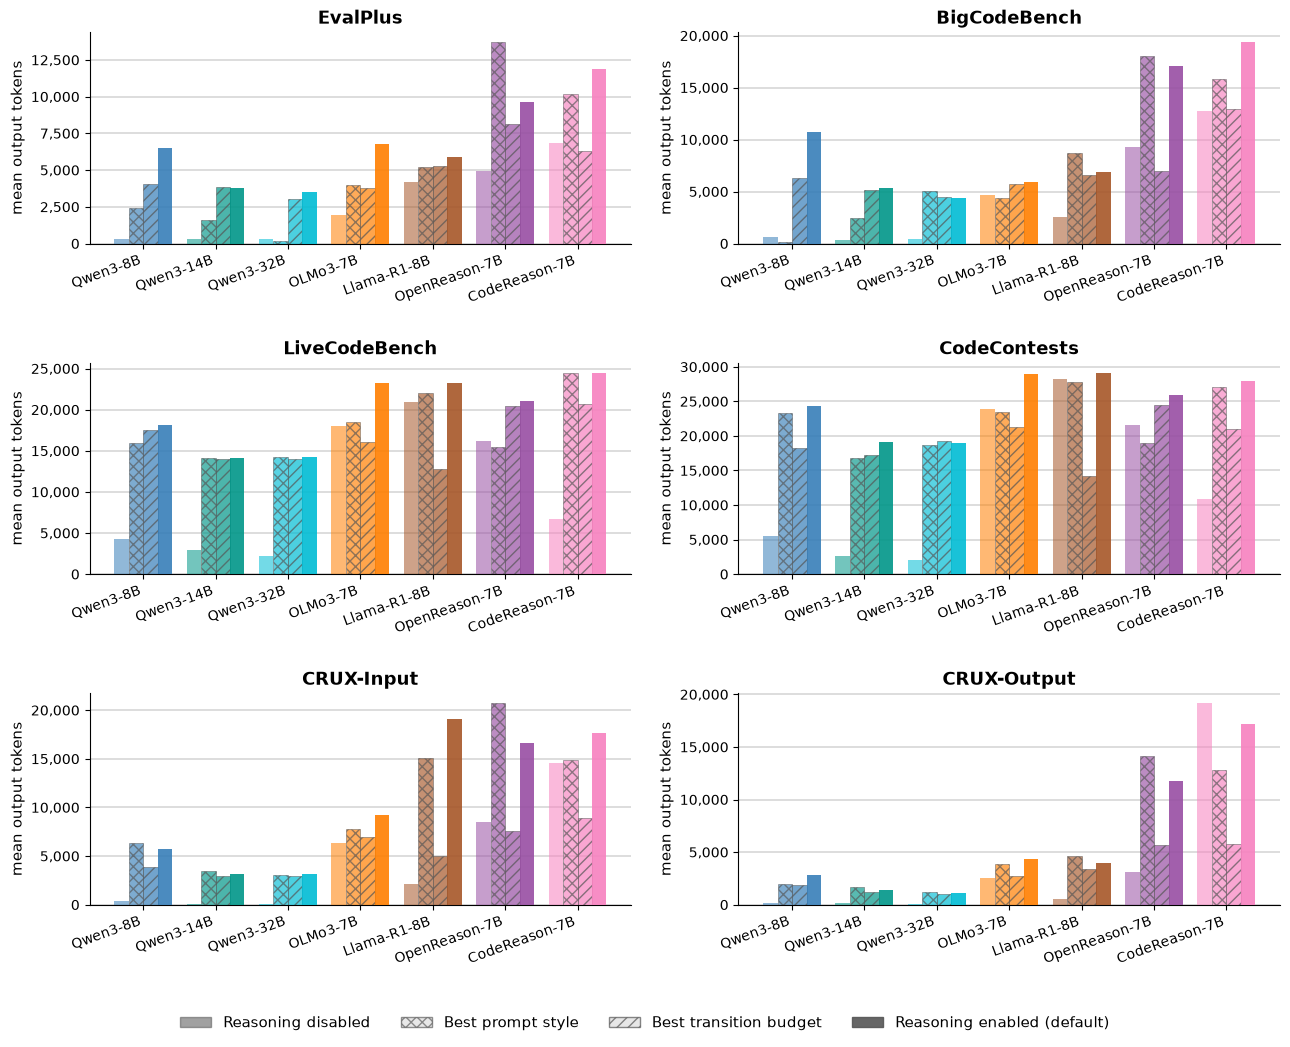

In [5]:
# --- mean output tokens per regime, per benchmark ---
# bar colour = model, alpha/hatch = regime (disabled / best prompt style / best budget / default)

plot_regime_bars(
    data=all_data,
    metric="tokens",
    ylabel="mean output tokens",
    save_path=FIGURES_DIR / "06_efficiency_output_tokens.png",
)

In [6]:
def average_over_benchmarks(
    data: dict[str, dict[str, dict[str, dict]]],
) -> dict[str, dict[str, dict[str, float | None]]]:
    """Macro-average tokens and cost-per-correct-answer over all benchmarks.

    Every benchmark counts equally, and benchmarks with a missing entry are left out
    of the average rather than counted as zero.

    Returns a nested dict: series_key → regime_key → {"tokens": float|None, "cost": float|None}
    """
    averages: dict[str, dict[str, dict[str, float | None]]] = {}

    for series_key in SERIES:
        averages[series_key] = {}

        for regime_key in REGIMES:
            entry: dict[str, float | None] = {}

            for metric in ("tokens", "cost"):
                values = [
                    data[series_key][ds_label][regime_key][metric]
                    for ds_label in DATASETS
                    if data[series_key][ds_label][regime_key][metric] is not None
                ]
                entry[metric] = sum(values) / len(values) if values else None

            averages[series_key][regime_key] = entry

    return averages


avg_data = average_over_benchmarks(all_data)
print("averaged", len(DATASETS), "benchmarks per model and regime")

averaged 6 benchmarks per model and regime


saved → ../figures/06_efficiency_average.png


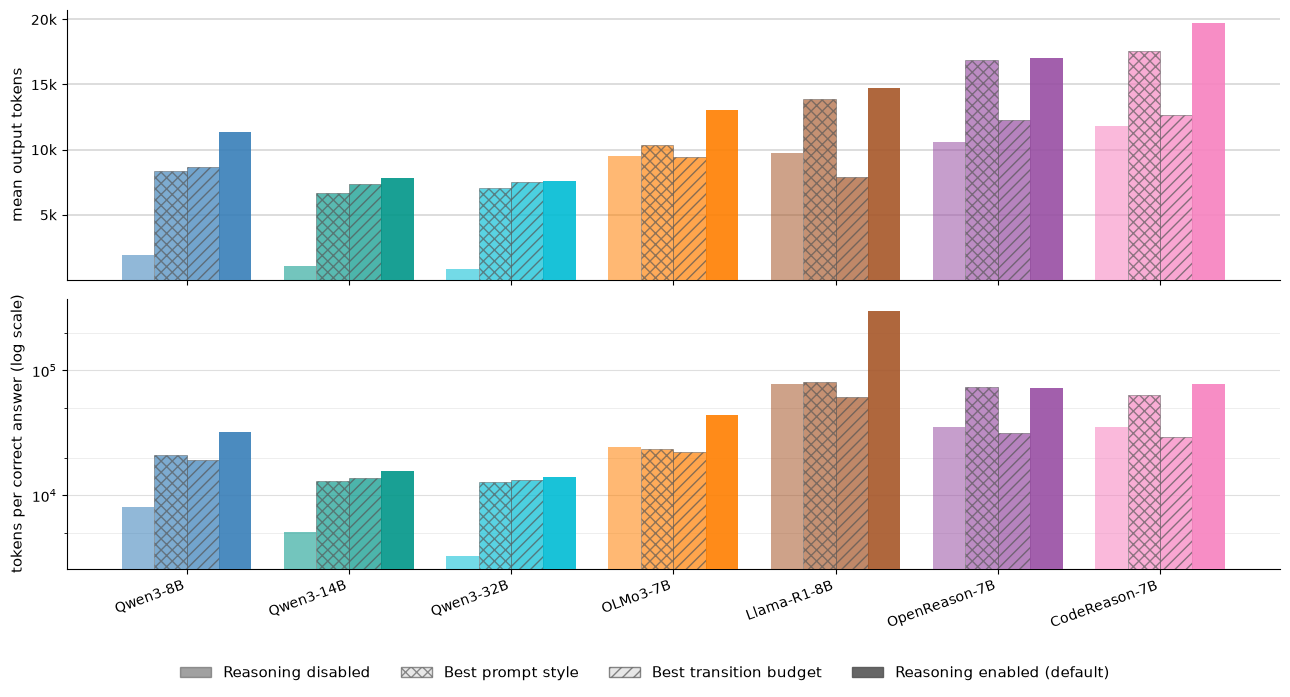

In [7]:
def plot_combined_average_bars(
    averages: dict[str, dict[str, dict[str, float | None]]],
    save_path: Path,
) -> None:
    """Plot both macro-averaged metrics in one figure: mean output tokens on top,
    tokens per correct answer (log scale) below.

    Same bar geometry and colour/hatch encoding as plot_regime_bars, but two stacked
    panels averaged over all benchmarks rather than one subplot per benchmark. Panels
    have no heading — the y-axis label identifies each metric — and share a single
    legend placed close beneath the bottom panel. The linear and log y-axis tick labels
    have different widths, which would otherwise leave the two panels' plot areas (and
    their y-axis titles) at different horizontal offsets, so both are explicitly
    realigned after layout. Saves the figure as a PNG at save_path.
    """
    fig, (ax_tokens, ax_cost) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(13, 7.0),
        sharex=True,
    )

    def get_tokens(series_key: str, regime_key: str) -> float | None:
        return averages[series_key][regime_key]["tokens"]

    def get_cost(series_key: str, regime_key: str) -> float | None:
        return averages[series_key][regime_key]["cost"]

    _draw_regime_bars(
        ax=ax_tokens, get_bar=get_tokens, title="", ylabel="mean output tokens"
    )
    # sparser ticks in thousands (5k/10k/15k/20k) — the default comma-formatted ticks
    # were too dense for this panel's smaller range
    ax_tokens.yaxis.set_major_locator(mticker.FixedLocator([5000, 10000, 15000, 20000]))
    ax_tokens.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x / 1000)}k")
    )

    _draw_regime_bars(
        ax=ax_cost,
        get_bar=get_cost,
        title="",
        ylabel="tokens per correct answer (log scale)",
        yscale="log",
    )
    # top panel's x-tick labels duplicate the (shared) bottom panel's — hide them
    ax_tokens.tick_params(axis="x", labelbottom=False)

    _add_regime_legend(fig, y=0.0)

    fig.tight_layout(rect=(0, 0.07, 1, 1), h_pad=1.0)

    # equalize the two panels' plot areas so bars line up vertically — tick label
    # widths differ (linear "20k" vs. log "10^5"), which otherwise shifts each
    # panel's plotting area independently
    fig.canvas.draw()
    pos_tokens = ax_tokens.get_position()
    pos_cost = ax_cost.get_position()
    left = max(pos_tokens.x0, pos_cost.x0)
    right = min(pos_tokens.x1, pos_cost.x1)
    ax_tokens.set_position([left, pos_tokens.y0, right - left, pos_tokens.height])
    ax_cost.set_position([left, pos_cost.y0, right - left, pos_cost.height])

    # align the y-axis titles so they sit at the same horizontal position
    fig.align_ylabels([ax_tokens, ax_cost])

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved → {save_path}")
    plt.show()


# --- mean output tokens and cost per correct answer, macro-averaged over all benchmarks ---

plot_combined_average_bars(
    averages=avg_data,
    save_path=FIGURES_DIR / "06_efficiency_average.png",
)

saved → ../figures/06_efficiency_cost_per_correct.png


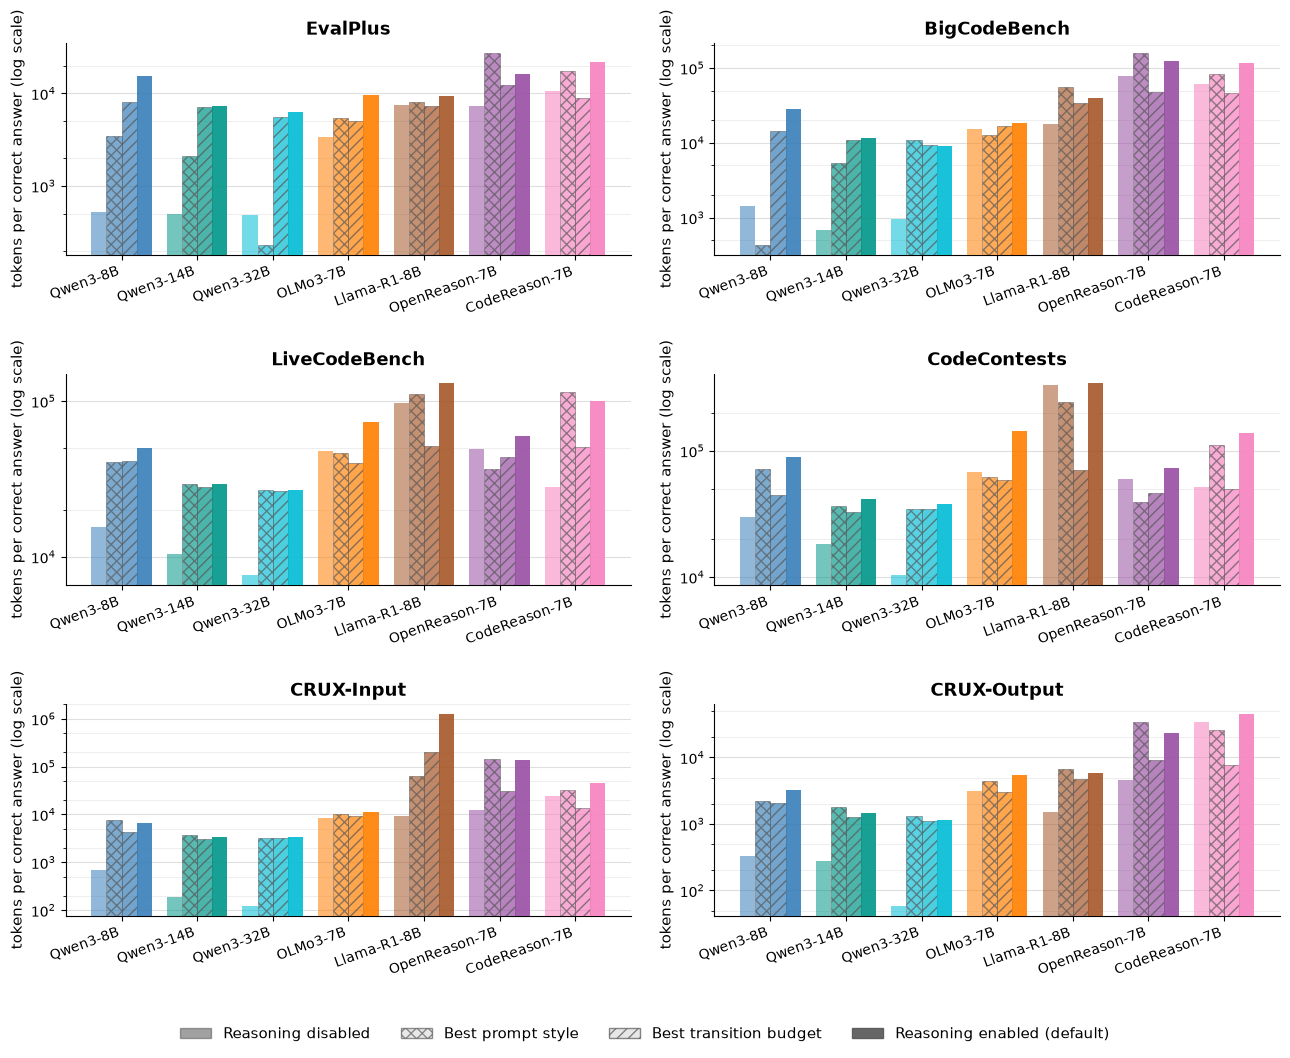

In [8]:
# --- tokens spent per correct answer, per regime, per benchmark ---
# cost = mean output tokens / pass@1 — undefined (left blank) wherever pass@1 is 0.
# log scale: benchmarks and models with low accuracy can cost orders of magnitude more
# tokens per correct answer than high-accuracy ones.

plot_regime_bars(
    data=all_data,
    metric="cost",
    ylabel="tokens per correct answer (log scale)",
    save_path=FIGURES_DIR / "06_efficiency_cost_per_correct.png",
    yscale="log",
)

In [9]:
# --- summary table: macro average over benchmarks, Δ vs. onepass (reasoning enabled, default) ---

COL_M = max(len(s["label"]) for s in SERIES.values()) + 2
COL_R = max(len(r["label"]) for r in REGIMES.values()) + 2

BASELINE_REGIME = "onepass"


def _delta_tokens(value: float | None, base: float | None) -> str:
    """Format the change in mean tokens against the baseline, or blank if unavailable."""
    if value is None or base is None:
        return ""
    return f"{value - base:+,.0f}"


print(
    f"{'model':{COL_M}}  {'regime':{COL_R}}  {'tokens':>10}  {'Δ tokens':>10}  "
    f"{'cost/correct':>13}"
)
print(f"{'─' * COL_M}  {'─' * COL_R}  {'─' * 10}  {'─' * 10}  {'─' * 13}")

for series_key, series_info in SERIES.items():
    means = avg_data[series_key]
    base = means[BASELINE_REGIME]

    for row_idx, (regime_key, regime_info) in enumerate(REGIMES.items()):
        row = means[regime_key]
        model_cell = series_info["label"] if row_idx == 0 else ""
        tokens_str = f"{row['tokens']:,.0f}" if row["tokens"] is not None else "—"
        cost_str = f"{row['cost']:,.0f}" if row["cost"] is not None else "—"
        tokens_d = (
            ""
            if regime_key == BASELINE_REGIME
            else _delta_tokens(row["tokens"], base["tokens"])
        )

        print(
            f"{model_cell:{COL_M}}  {regime_info['label']:{COL_R}}  {tokens_str:>10}  "
            f"{tokens_d:>10}  {cost_str:>13}"
        )
    print()

model            regime                             tokens    Δ tokens   cost/correct
───────────────  ─────────────────────────────  ──────────  ──────────  ─────────────
Qwen3-8B         Reasoning disabled                  1,878      -9,501          8,122
                 Best prompt style                   8,374      -3,006         20,939
                 Best transition budget              8,641      -2,739         19,179
                 Reasoning enabled (default)        11,380                     32,209

Qwen3-14B        Reasoning disabled                  1,085      -6,727          5,066
                 Best prompt style                   6,687      -1,124         13,149
                 Best transition budget              7,389        -422         13,886
                 Reasoning enabled (default)         7,811                     15,791

Qwen3-32B        Reasoning disabled                    837      -6,727          3,252
                 Best prompt style                  